In [1]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import rosbag
from tf.transformations import euler_from_quaternion
from tqdm import tqdm

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


INFO - 2025-10-13 19:24:20,623 - topics - topicmanager initialized


In [2]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import rosbag
from tf.transformations import euler_from_quaternion
from tqdm import tqdm


# def get_grid_lineset(h_min_val, h_max_val, w_min_val, w_max_val, ignore_axis, grid_length=1, nth_line=5):
#     if (h_min_val%2!=0):
#         h_min_val -= 1
#     if (h_max_val%2!=0):
#         h_max_val += 1
#     if (w_min_val%2!=0):
#         w_min_val -= 1
#     if (w_max_val%2!=0):
#         w_max_val += 1
    
#     num_h_grid = int(np.ceil((h_max_val - h_min_val) / grid_length))
#     num_w_grid = int(np.ceil((w_max_val - w_min_val) / grid_length))
    
#     num_h_grid_mid = num_h_grid // 2
#     num_w_grid_mid = num_w_grid // 2
    
#     grid_vertexes_order = np.zeros((num_h_grid, num_w_grid)).astype(np.int16)
#     grid_vertexes = []
#     vertex_order_index = 0
    
#     for h in range(num_h_grid):
#         for w in range(num_w_grid):
#             grid_vertexes_order[h][w] = vertex_order_index
#             if ignore_axis == 0:
#                 grid_vertexes.append([0, grid_length*w + w_min_val, grid_length*h + h_min_val])
#             elif ignore_axis == 1:
#                 grid_vertexes.append([grid_length*h + h_min_val, 0, grid_length*w + w_min_val])
#             elif ignore_axis == 2:
#                 grid_vertexes.append([grid_length*w + w_min_val, grid_length*h + h_min_val, 0])
#             else:
#                 pass                
#             vertex_order_index += 1       
            
#     next_h = [0, 1]
#     next_w = [1, 0]
#     grid_lines = []
#     grid_nth_lines = []
#     for h in range(num_h_grid):
#         for w in range(num_w_grid):
#             here_h = h
#             here_w = w
#             for i in range(2):
#                 there_h = h + next_h[i]
#                 there_w = w +  next_w[i]   
#                 if (0 <= there_h and there_h < num_h_grid) and (0 <= there_w and there_w < num_w_grid):
#                     if ((here_h % nth_line) == 0) and ((here_w % nth_line) == 0):
#                         grid_nth_lines.append([grid_vertexes_order[here_h][here_w], grid_vertexes_order[there_h][there_w]])
#                     elif ((here_h % nth_line) != 0) and ((here_w % nth_line) == 0) and i == 1:
#                         grid_nth_lines.append([grid_vertexes_order[here_h][here_w], grid_vertexes_order[there_h][there_w]])
#                     elif ((here_h % nth_line) == 0) and ((here_w % nth_line) != 0) and i == 0:
#                         grid_nth_lines.append([grid_vertexes_order[here_h][here_w], grid_vertexes_order[there_h][there_w]])
#                     else:
#                         grid_lines.append([grid_vertexes_order[here_h][here_w], grid_vertexes_order[there_h][there_w]])

#     color = (0.8, 0.8, 0.8)
#     colors = [color for i in range(len(grid_lines))]
#     line_set = o3d.geometry.LineSet(
#         points=o3d.utility.Vector3dVector(grid_vertexes),
#         lines=o3d.utility.Vector2iVector(grid_lines),
#     )
#     line_set.colors = o3d.utility.Vector3dVector(colors)
    
#     color = (255, 0, 0)
#     colors = [color for i in range(len(grid_nth_lines))]
#     line_nth_set = o3d.geometry.LineSet(
#         points=o3d.utility.Vector3dVector(grid_vertexes),
#         lines=o3d.utility.Vector2iVector(grid_nth_lines),
#     )
#     line_nth_set.colors = o3d.utility.Vector3dVector(colors)
    
#     return line_set, line_nth_set

# def show_open3d_pcd(raw, show_origin=True, origin_size=3, 
#                     show_grid=True, grid_len=1, 
#                     voxel_size=0, 
#                     range_min_xyz=(-80, -80, -80), range_max_xyz=(80, 80, 80)):
#     '''
#     - raw : numpy 2d array (size : (n, 3)) or o3d.geometry.PointCloud
#     - show_origin : show origin XYZ coordinate. (X=red, Y=green, Z=Blue)
#     - origin_size : size of origin coordinate.
#     - show_grid : if true, show grid in xy, yz, zx plane with 'grid_len' length (default : gray line) and 5 times of 'grid_len' (default : red line)
#     - voxel_size : voxel size to downsampling
#     - range_min_xyz : grid min range of xyz orientation
#     - range_max_xyz : grid max range of xyz orientation

#     '''
#     pcd = o3d.geometry.PointCloud()    
    
#     if isinstance(raw, type(pcd)):
#         pcd = raw
#     elif isinstance(raw, np.ndarray):
#         pcd.points = o3d.utility.Vector3dVector(raw)        
#     if voxel_size > 0:
#         pcd = pcd.voxel_down_sample(voxel_size=voxel_size)
        
#     pcd_point = np.array(pcd.points)
#     inrange_inds = (pcd_point[:, 0] > range_min_xyz[0]) & \
#                     (pcd_point[:, 1] > range_min_xyz[1]) & \
#                     (pcd_point[:, 2] > range_min_xyz[2]) & \
#                     (pcd_point[:, 0] < range_max_xyz[0]) & \
#                     (pcd_point[:, 1] < range_max_xyz[1]) & \
#                     (pcd_point[:, 2] < range_max_xyz[2])    
    
#     pcd_point = pcd_point[inrange_inds]
#     filtered_raw = pcd_point
#     pcd.points = o3d.utility.Vector3dVector(filtered_raw)
        
#     x_min_val, y_min_val, z_min_val = range_min_xyz
#     x_max_val, y_max_val, z_max_val = range_max_xyz
    
#     coord = o3d.geometry.TriangleMesh().create_coordinate_frame(size=origin_size, origin=np.array([0.0, 0.0, 0.0]))
    
#     ##################################### grid 생성 코드 ######################################
#     lineset_yz, lineset_nth_yz = get_grid_lineset(z_min_val, z_max_val, y_min_val, y_max_val, 0, grid_len)
#     lineset_zx, lineset_nth_zx = get_grid_lineset(x_min_val, x_max_val, z_min_val, z_max_val, 1, grid_len)
#     lineset_xy, lineset_nth_xy = get_grid_lineset(y_min_val, y_max_val, x_min_val, x_max_val, 2, grid_len) 
#     ###########################################################################################
    
#     # set front, lookat, up, zoom to change initial view
#     if show_origin and show_grid:
#         o3d.visualization.draw_geometries([pcd, coord,
#                                            lineset_nth_yz, lineset_nth_zx, lineset_nth_xy,
#                                            lineset_xy, lineset_yz, lineset_zx
#                                           ])  
#     elif show_origin and not show_grid:
#         o3d.visualization.draw_geometries([pcd, coord])
#     elif not show_origin and show_grid:
#         o3d.visualization.draw_geometries([pcd,
#                                            lineset_nth_yz, lineset_nth_zx, lineset_nth_xy,
#                                            lineset_xy, lineset_yz, lineset_zx
#                                           ])  
#     else:
#         o3d.visualization.draw_geometries([pcd])  

def pose2d_to_mat4(x, y, yaw):
    """
    2D pose (x, y, yaw) → 4x4 homogeneous transform (SE3)
    yaw 단위: rad
    """
    c, s = np.cos(yaw), np.sin(yaw)
    T = np.eye(4)
    T[0,0], T[0,1] = c, -s
    T[1,0], T[1,1] = s,  c
    T[0,3], T[1,3] = x, y
    return T

def mat4_to_pose2d(T):
    x, y = T[0,3], T[1,3]
    yaw = np.arctan2(T[1,0], T[0,0])
    return x, y, yaw

def T_w_c_to_T_w_o(T_w_c):
    """
    카메라 좌표계에서 오브젝트 좌표계로 변환
    T_w_c: 월드 좌표계에서 카메라 좌표계로의 변환 행렬 (4x4)
    T_w_o: 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 (4x4)
    """
    # 카메라 좌표계에서 오브젝트 좌표계로의 변환 행렬 (예: 90도 회전)
    T_c_o = np.array([[0, -1, 0, 0],
                      [0, 0, -1, 0],
                      [1, 0, 0, 0],
                      [0, 0, 0, 1]])
    
    # 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 계산
    T_w_o = np.dot(T_w_c, T_c_o)
    
    return T_w_o

def T_w_o_to_T_w_c(T_w_o):
    """
    오브젝트 좌표계에서 카메라 좌표계로 변환
    T_w_o: 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 (4x4)
    T_w_c: 월드 좌표계에서 카메라 좌표계로의 변환 행렬 (4x4)
    """
    # 오브젝트 좌표계에서 카메라 좌표계로의 변환 행렬 (예: -90도 회전)
    T_o_c = np.array([[0, 0, 1, 0],
                      [-1, 0, 0, 0],
                      [0, -1, 0, 0],
                      [0, 0, 0, 1]])
    
    # 월드 좌표계에서 카메라 좌표계로의 변환 행렬 계산
    T_w_c = np.dot(T_w_o, T_o_c)
    
    return T_w_c


def project_to_se2_camera(T: np.ndarray) -> np.ndarray:
    """
    임의의 SE(3) 변환 T를 카메라 좌표계(z-forward, x-right, y-down) 기준에서
    (z, x, yaw)만 남기는 4x4로 투영.
    yaw는 y축(수직축) 회전으로 정의.
    """
    # yaw 추출 (y축 회전)
    yaw = np.arctan2(T[0,2], T[2,2])  # R[0,2]/R[2,2]

    c, s = np.cos(yaw), np.sin(yaw)

    Tout = np.eye(4)
    # y축 회전 행렬 (camera convention: z-forward, x-right, y-down)
    Tout[0,0], Tout[0,2] =  c, s
    Tout[2,0], Tout[2,2] = -s, c
    Tout[1,1] = 1.0

    # 평행이동은 x(right), z(forward)만 유지, y는 그대로 두되 나중에 필요없으면 0으로
    Tout[0,3] = T[0,3]  # x
    Tout[1,3] = 0.0     # y는 무시 (수평 이동만 고려)
    Tout[2,3] = T[2,3]  # z

    return Tout

# def pose2d_to_mat4_cam(x, y, yaw):
#     """
#     2D pose (x, y, yaw) → 4x4 homogeneous transform (SE3)
#     input x, y, yaw are in body coordinate (x-forward, y-left, z-up)
#     in camera coordinate (z-forward, x-right, y-down)

#     yaw 단위: rad
#     """
#     c, s = np.cos(yaw), np.sin(yaw)

#     Tout = np.eye(4)
#     # y축 회전 행렬 (camera convention: z-forward, x-right, y-down)
#     Tout[0,0], Tout[0,2] =  c, -s
#     Tout[2,0], Tout[2,2] = s, c
#     # 평행이동은 x(right), z(forward)만 유지, y는 그대로 두되 나중에 필요없으면 0으로
#     Tout[0,3] = -y
#     Tout[2,3] = x
#     return Tout

# def mat4_to_pose2d_cam(T):
#     x, y = T[2,3], -T[0,3]
#     yaw = -np.arctan2(T[0,2], T[2,2])
#     return x, y, yaw

In [3]:
# import copy
# # varify pose2d_to_mat4_cam, mat4_to_pose2d_cam with coordinate of o3d
# x,y,yaw = 1.0, 2.0, np.deg2rad(30)
# T = pose2d_to_mat4_cam(x,y,yaw)
# x2, y2, yaw2 = mat4_to_pose2d_cam(T)
# print(f"input: {x,y,np.rad2deg(yaw)}")
# print(f"output: {x2,y2,np.rad2deg(yaw2)}")
# assert np.isclose(x, x2) and np.isclose(y, y2) and np.isclose(yaw, yaw2)

# coord = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0]))
# T_w_c = T_w_o_to_T_w_c(np.eye(4))
# coord_cam = copy.deepcopy(coord)
# coord_cam = coord_cam.transform(T_w_c)


# T1 = pose2d_to_mat4(x,y,yaw)
# coord1 = copy.deepcopy(coord_cam)
# coord1 = coord1.transform(T1)
# # translation = T1[0:3, 3]
# # rotation = T1[0:3, 0:3]
# # coord1.translate(translation)
# # coord1.rotate(rotation, center=translation)

# coord.scale(0.5, center=coord.get_center())

# o3d.visualization.draw_geometries([coord, coord_cam, coord1])

# Load rosbag data

In [4]:

# ===============================
# 1. 데이터 로드 (사용자 준비)
# ===============================
# 예시: rgb_list, depth_list, vo_poses는 미리 준비된 리스트
#  - rgb_list: (H, W, 3) numpy array
#  - depth_list: (H, W) numpy array, 사람 영역은 mask된 depth
#  - vo_poses: 각 프레임의 VO pose (4x4 numpy array)

import cv2

rgb_list = [] 
rgb_time = [] 
depth_list = []  
depth_time = [] 
vo_poses = []      # VO trajectory (각각 4x4 pose)
vo_time = []  
object_detect = []  # 각 프레임의 객체 검출 결과 (사용자 정의 형식)
object_time = []  # 객체 검출 시간 리스트
target_pose = []  # 각 프레임의 객체 검출 결과 (3D 좌표)
target_pose_time = []


# for gtsam
poses2d = []  # (x, y, yaw) 리스트
covs2d = []  # 3x3 공분산 리스트



bagfile = "/media/seungwoo/T5_JSW/rosbag_alchemist_2025_08_01/office/1/2025-08-01-20-10-58.bag"
odom_topic = "/zed2/zed_node/odom"
depth_topic = "/zed_client/image_depth_masked"
rgb_topic = "/zed2/zed_node/rgb/image_rect_color"
obj_det_topic = "/zed2/zed_node/obj_det/objects"
target_pose_topic = "/zed_client/object1_position"


# fig, ax = plt.subplots(1, 1)
# plt.ion()
# ax.set_title("Depth Image")
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# img_plot = ax.imshow(np.zeros((480, 640)), cmap='gray')
# colorbar = plt.colorbar(img_plot, ax=ax)
# plt.pause(0.1)  # 잠시 표시

with rosbag.Bag(bagfile) as bag:
    for topic, msg, t in tqdm(bag.read_messages(topics=[rgb_topic, depth_topic, odom_topic, obj_det_topic,target_pose_topic]), desc="Loading data from bag",):
        if topic == rgb_topic:
            rgb = np.frombuffer(msg.data, dtype=np.uint8).reshape(msg.height, msg.width, -1).copy()
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
            rgb_list.append(rgb)
            rgb_time.append(t)
        elif topic == depth_topic:
            depth = np.frombuffer(msg.data, dtype=np.float32).reshape(msg.height, msg.width).copy()
            # img_plot.set_data(depth)
            # img_plot.set_clim(vmin=np.nanmin(depth), vmax=np.nanmax(depth))
            # plt.pause(0.001)
            depth_list.append(depth)
            depth_time.append(t)
        elif topic == odom_topic:
            
            x = msg.pose.pose.position.x
            y = msg.pose.pose.position.y
            z = 0  # 2D이므로 z=0 고정
            # orientation quaternion -> yaw
            q = msg.pose.pose.orientation
            quat = [q.x, q.y, q.z, q.w]
            roll, pitch, yaw = euler_from_quaternion(quat)
            T = pose2d_to_mat4(x, y, yaw)
            vo_poses.append(T)
            poses2d.append((x, y, yaw))
            cov = np.array(msg.pose.covariance).reshape(6,6)
            cov_2d_cur = cov[np.ix_([0,1,5],[0,1,5])]  # x, y, yaw에 해당하는 부분 추출
            covs2d.append(cov_2d_cur)
            vo_time.append(t)
        elif topic == obj_det_topic:
            object_detect.append(msg)  # 사용자 정의 형식에 맞게 저장
            object_time.append(t)
        elif topic == target_pose_topic:
            object_detect_xyz = np.array([msg.point.x, msg.point.y, msg.point.z], dtype=np.float32)
            target_pose.append(object_detect_xyz)
            target_pose_time.append(t)


# 시간 동기화 (가장 가까운 시간의 depth/rgb/vo 매칭)
synced_rgb = []
synced_depth = []
synced_vo_poses = []
synced_pose2d = []
synced_cov2d = []
synced_object_detect = []
synced_target_pose = []
for i in range(len(depth_time)):
    depth_t = depth_time[i]
    # 가장 가까운 rgb 찾기
    rgb_diffs = [abs((depth_t - rt).to_sec()) for rt in rgb_time]
    rgb_idx = np.argmin(rgb_diffs)
    # 가장 가까운 vo 찾기
    vo_diffs = [abs((depth_t - vt).to_sec()) for vt in vo_time]
    vo_idx = np.argmin(vo_diffs)
    # 가장 가까운 object detection 찾기
    obj_diffs = []
    for ot in object_time:
        if (depth_t - ot).to_sec() > 0:
            obj_diffs.append(abs((depth_t - ot).to_sec()))
        else:
            obj_diffs.append(float('inf'))
    obj_idx = np.argmin(obj_diffs)
    target_pose_diffs = []
    for tt in target_pose_time:
        if (depth_t - tt).to_sec() > 0:
            target_pose_diffs.append(abs((depth_t - tt).to_sec()))
        else:
            target_pose_diffs.append(float('inf'))
    target_idx = np.argmin(target_pose_diffs)

    # gbr = rgb_list[rgb_idx]
    # rgb = gbr.copy()
    # rgb[:,:,0] = gbr[:,:,2]
    # rgb[:,:,2] = gbr[:,:,0]
    synced_rgb.append(rgb_list[rgb_idx])
    synced_depth.append(depth_list[i])  # depth는 현재 인덱스 사용
    synced_vo_poses.append(vo_poses[vo_idx])
    synced_pose2d.append(poses2d[vo_idx])
    synced_cov2d.append(covs2d[vo_idx])
    synced_object_detect.append(object_detect[obj_idx])
    synced_target_pose.append(target_pose[target_idx])


rgb_list = synced_rgb
depth_list = synced_depth
vo_poses = synced_vo_poses
object_detect = synced_object_detect
poses2d = synced_pose2d
covs2d = synced_cov2d
vo_cam_pose = T_w_o_to_T_w_c(synced_vo_poses)  # 카메라 좌표계에서의 VO pose (4x4 numpy array)
target_pose = synced_target_pose


Loading data from bag: 3290it [00:10, 308.20it/s]


In [5]:

for i in range(len(target_pose)):
    # make relative position to camera
    tar = target_pose[i]
    cur_vo = vo_poses[i]
    tar_cam = np.linalg.inv(cur_vo) @ np.array([tar[0], tar[1], tar[2], 1.0])
    target_pose[i] = tar_cam[:3]


### trim multi man frame

In [6]:
tmp_list = np.array([len(object_detect[i].objects) for i in range(len(object_detect))])

double_man_indxes = np.where(tmp_list>1)[0]
double_man_indxes


array([134, 135, 141, 142, 148, 150, 151, 156, 157, 165, 171, 209, 210,
       211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223,
       224, 225, 226, 227, 228, 229, 230, 231, 254, 255, 256, 257, 258,
       259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271,
       272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284,
       365, 371, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425,
       426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438,
       439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451,
       452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464,
       465, 466, 467, 468, 469, 495, 502, 510, 511, 512, 513, 514, 515,
       516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528,
       529, 530, 545, 549, 563, 566, 571, 577, 583, 584, 585, 586, 587,
       588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600,
       601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 61

In [7]:
tmp_list = [[object_detect[i].objects[j].confidence for j in range(len(object_detect[i].objects))] for i in range(len(object_detect))]
max_conf = []
for tmp in tmp_list:
    if len(tmp)>1:
        max_conf.append(max(tmp))
    else:
        max_conf.append(tmp[0])

tmp_arr = np.array(max_conf)
high_conf_inds = np.where(tmp_arr<70)[0]
high_conf_inds


array([], dtype=int64)

In [8]:

for i in double_man_indxes:

    rGlobalMin = 0
    cGlobalMin = 0
    rGlobalMax = 320-1
    cGlobalMax = 640-1
    x_padding = 5
    y_padding = 0
 
    # plt.imshow(depth_list[i])
    # plt.imshow(rgb_list[i])
    for det in object_detect[i].objects:
        # if det.confidence > 70 :
        #     continue
        bound = [det.bounding_box_2d.corners[j].kp for j in range(4)]
        bound = np.array(bound, dtype=int) /2

        rMin = max(int(np.min(bound[:,1])) - y_padding, rGlobalMin)
        rMax = min(int(np.max(bound[:,1])) + y_padding, rGlobalMax)
        cMin = max(int(np.min(bound[:,0])) - x_padding, cGlobalMin)
        cMax = min(int(np.max(bound[:,0])) + x_padding, cGlobalMax)
        depth_list[i][rMin:rMax, cMin:cMax] = np.nan
        # plt.plot([cMin, cMax, cMax, cMin, cMin], [rMin, rMin, rMax, rMax, rMin], 'r-')
        # print(det.confidence)
    # plt.show()
    # break
    

### get pcl


In [9]:


# test pcl

index = double_man_indxes[-1]

fx=261.167
fy=261.167
cx=323.5188
cy=179.9977
width, height = 640, 360
intrinsic = o3d.camera.PinholeCameraIntrinsic(width, height, fx, fy, cx, cy)

tmp_rgb_image = rgb_list[index]
rgb = cv2.cvtColor(tmp_rgb_image, cv2.COLOR_RGB2BGR)

rgb_o3d = o3d.geometry.Image(rgb.astype(np.uint8))
depth_o3d = o3d.geometry.Image(depth_list[index].astype(np.float32))
rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
    rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=5.0,
    convert_rgb_to_intensity=False
)
prev_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
prev_pcd.transform(vo_cam_pose[index])  # 카메라 좌표계 → 월드 좌표계

coords = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
coords.transform(vo_cam_pose[index])

o3d.visualization.draw_geometries([prev_pcd, coords])


In [10]:

# visualize first five frames

coords_list = [o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64)) for _ in range(5)]
pcl_list = []
for i in range(5):
    coords_list[i].scale(0.5, center=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    
    coords_list[i].transform(vo_cam_pose[i*20])
    # coords_list[i].transform(vo_poses[i*20])

    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        o3d.geometry.Image(rgb_list[i*20].astype(np.uint8)),
        o3d.geometry.Image(depth_list[i*20].astype(np.float32)),
        depth_scale = 1.0, depth_trunc=5.0,
        convert_rgb_to_intensity=False
    )

    pcl_list.append(o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic))
    pcl_list[-1].transform(vo_cam_pose[i*20])
    # pcl_list.append(o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic))
    

o3d.visualization.draw_geometries([*coords_list, *pcl_list])


In [11]:
o3d.visualization.draw_geometries([pcl_list[-1]])

In [12]:
# speckle removal
# pcd: o3d.geometry.PointCloud
# 반경 r(m) 안에 최소 nb_points 개의 이웃이 없으면 제거
index = 280

voxel_size = 0.05  # point cloud downsample voxel size (m)
depth_trunc = 4.5  # 사용할 depth 범위 (m)
nb_neighbors = 30  # 통계적 이상치 제거 이웃 개수
std_ratio = 0.3  # 통계적 이상치 제거 표준편차 배수

rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        o3d.geometry.Image(rgb_list[index].astype(np.uint8)),
        o3d.geometry.Image(depth_list[index].astype(np.float32)),
        depth_scale = 1.0, depth_trunc=depth_trunc,
        convert_rgb_to_intensity=False
    )

pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
pcd = pcd.voxel_down_sample(voxel_size=voxel_size)
pcd.transform(vo_cam_pose[index])

coord = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
coord.transform(vo_cam_pose[index])

pcd_clean, ind_inliers = pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors,std_ratio=std_ratio)
# pcd_clean, ind_inliers = pcd.remove_radius_outlier(nb_points=16, radius=0.05)

# 필요하면 outlier만 따로 보고 싶다면
# outlier_indices = [i for i in range(len(pcd.points)) if i not in set(ind_inliers)]
# pcd_out = pcd.select_by_index(outlier_indices)

# 시각화 (인라이어=회색, 아웃라이어=빨강)
pcd_vis = pcd_clean.paint_uniform_color([0.7, 0.7, 0.7])
# pcd_out.paint_uniform_color([1.0, 0.0, 0.0])
# o3d.visualization.draw_geometries([pcd_vis, pcd_out])
o3d.visualization.draw_geometries([coord, pcd, pcd_vis])

In [13]:
coords = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
coords.transform(vo_poses[0])

# o3d.visualization.draw_geometries([prev_pcd, coords])
# show_open3d_pcd(prev_pcd, show_origin=True, origin_size=1, show_grid=True, grid_len=1, voxel_size=0.05,
#                 range_min_xyz=(-10, -10, -2), range_max_xyz=(10, 10, 3))

TriangleMesh with 1134 points and 2240 triangles.

## ICP 

In [14]:
# # ===============================
# # 2. ICP로 VO trajectory 정제
# # ===============================
# import copy
# visualize = True
# start_frame = 0
# end_frame = len(depth_list)
# frame_step = 1  # 몇 프레임마다 처리할지 (속도 조절용)

# voxel_size = 0.05  # point cloud downsample voxel size (m)
# depth_trunc = 5.0  # 사용할 depth 범위 (m)

# refined_poses = [vo_cam_pose[start_frame]]
# residual = []
# prev_idx = start_frame


# if visualize:
#     pcl_list = []
#     coords_list = []
#     pcl_after_list = []
#     coords_after_list = []


# # 첫 번째 프레임으로 prev_pcd 초기화
# rgb_o3d = o3d.geometry.Image(rgb_list[start_frame].astype(np.uint8))
# depth_o3d = o3d.geometry.Image(depth_list[start_frame].astype(np.float32))
# rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
#     rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=depth_trunc,
#     convert_rgb_to_intensity=False
# )
# prev_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)

# if visualize:
#     coords = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
#     coords.transform(vo_cam_pose[start_frame])

#     coords_list.append(coords)
#     coords_after_list.append(coords)

#     pcl_tmp = copy.deepcopy(prev_pcd)
#     pcl_tmp.transform(vo_cam_pose[start_frame]) ##???
#     pcl_list.append(pcl_tmp)
#     pcl_after_list.append(pcl_tmp)

# prev_pcd = prev_pcd.voxel_down_sample(voxel_size)
# prev_pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))


# for i in range(start_frame+frame_step,end_frame, frame_step):
#     # RGBD 변환
#     cur_idx = i
#     rgb_o3d   = o3d.geometry.Image(rgb_list[cur_idx].astype(np.uint8))
#     depth_o3d = o3d.geometry.Image((depth_list[cur_idx]).astype(np.float32))

#     rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
#         rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=depth_trunc,
#         convert_rgb_to_intensity=False
#     )

#     pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
#     print(f"Frame {cur_idx}: Original points = {len(pcd.points)}")

#     if visualize:
#         coord = o3d.geometry.TriangleMesh().create_coordinate_frame(size=0.3, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
#         coord.transform(vo_cam_pose[cur_idx])
#         coords_list.append(coord)
#         pcl_tmp = copy.deepcopy(pcd)
#         pcl_tmp.transform(vo_cam_pose[cur_idx])
#         pcl_list.append(pcl_tmp)
    
#     pcd = pcd.voxel_down_sample(voxel_size)
#     pcd = pcd.remove_statistical_outlier(nb_neighbors=10,std_ratio=1.0)[0]
#     print(f"Frame {cur_idx}: Downsampled points = {len(pcd.points)}")
#     # Normal vector 계산
#     pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

#     # VO relative transform
#     T_guess = np.linalg.inv(vo_cam_pose[prev_idx]) @ vo_cam_pose[cur_idx]

#     # ICP
#     max_dist = (vo_time[cur_idx] - vo_time[prev_idx]).to_sec() # 1 m/s 이동 가정
#     print(max_dist, "m is assumed between frames")
#     reg = o3d.pipelines.registration.registration_icp(
#         pcd, prev_pcd,
#         max_correspondence_distance=max_dist * 1.5,
#         init=T_guess,
#         estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane()
#     )

#     # refined pose 업데이트
#     ref_ = project_to_se2_camera(reg.transformation)
#     T_refined = (refined_poses[-1] @ ref_).copy()
#     refined_poses.append(T_refined)
#     residual.append(reg.inlier_rmse)
#     print(f"Frame {cur_idx}: ICP inlier RMSE = {reg.inlier_rmse}")

#     if visualize:
#         pcd_tmp = copy.deepcopy(pcd)
#         pcd_tmp.transform(T_refined) 
#         pcl_after_list.append(pcd_tmp)
#         coord_after = o3d.geometry.TriangleMesh().create_coordinate_frame(size=0.3, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
#         coord_after.transform(T_refined)
#         coords_after_list.append(coord_after)

#     # keyframe 업데이트
#     prev_pcd = pcd
#     prev_idx = cur_idx

# print("Average residual:", np.mean(residual))

# if visualize:
#     # visulize results
#     origin = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
#     o3d.visualization.draw_geometries([origin, *coords_list, *pcl_list])
#     o3d.visualization.draw_geometries([*coords_after_list, *pcl_after_list])

In [15]:
# ===============================
# 2. ICP로 VO trajectory 정제
# ===============================
import copy
visualize = True
start_frame = 0
end_frame = len(depth_list)
# start_frame = 270
# end_frame = 280
# frame_step = 1  # 몇 프레임마다 처리할지 (속도 조절용)

voxel_size = 0.05  # point cloud downsample voxel size (m)
depth_trunc = 4.5  # 사용할 depth 범위 (m)
nb_neighbors = 30  # 통계적 이상치 제거 이웃 개수
std_ratio = 0.3  # 통계적 이상치 제거 표준편차 배수
# yaw_only = True  # 최적화의 yaw만 사용

refined_poses = [vo_cam_pose[start_frame]]
reg_list = []
prev_idx = start_frame

key_frame_intervals = 1  # 몇 프레임마다 키프레임 갱신할지 (속도 조절용)
key_frame_indices = [start_frame]
for kf in range(start_frame + key_frame_intervals, end_frame, key_frame_intervals):
    key_frame_indices.append(kf)
if key_frame_indices[-1] != end_frame - 1:
    key_frame_indices.append(end_frame - 1)
# print("Key frame indices:", key_frame_indices)

if visualize:
    pcl_list = []
    coords_list = []
    pcl_after_list = []
    coords_after_list = []

    t_guess = []
    t_reg = []


# 첫 번째 프레임으로 prev_pcd 초기화
rgb_o3d = o3d.geometry.Image(rgb_list[start_frame].astype(np.uint8))
depth_o3d = o3d.geometry.Image(depth_list[start_frame].astype(np.float32))
rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
    rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=depth_trunc,
    convert_rgb_to_intensity=False
)
prev_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
prev_pcd = prev_pcd.voxel_down_sample(voxel_size)
prev_pcd = prev_pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors,std_ratio=std_ratio)[0]

if visualize:
    coords = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    coords.transform(vo_cam_pose[start_frame])

    coords_list.append(coords)
    coords_after_list.append(coords)

    pcl_tmp = copy.deepcopy(prev_pcd)
    pcl_tmp.transform(vo_cam_pose[start_frame]) ##???
    pcl_list.append(pcl_tmp)
    pcl_after_list.append(pcl_tmp)


prev_pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))


# for i in range(start_frame+frame_step,end_frame, frame_step):
for i in range(start_frame+1,end_frame):
    
    # RGBD 변환
    cur_idx = i
    rgb_o3d   = o3d.geometry.Image(rgb_list[cur_idx].astype(np.uint8))
    depth_o3d = o3d.geometry.Image((depth_list[cur_idx]).astype(np.float32))

    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=depth_trunc,
        convert_rgb_to_intensity=False
    )

    pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
    # print(f"Frame {cur_idx}: Original points = {len(pcd.points)}")
    pcd = pcd.voxel_down_sample(voxel_size)
    pcd = pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors,std_ratio=std_ratio)[0]
    # print(f"Frame {cur_idx}: Downsampled points = {len(pcd.points)}")
    

    if visualize:
        coord = o3d.geometry.TriangleMesh().create_coordinate_frame(size=0.3, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
        coord.transform(vo_cam_pose[cur_idx])
        coords_list.append(coord)
        pcl_tmp = copy.deepcopy(pcd)
        pcl_tmp.transform(vo_cam_pose[cur_idx])
        pcl_list.append(pcl_tmp)
    
    
    # Normal vector 계산
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

    # VO relative transform
    T_guess = np.linalg.inv(vo_cam_pose[prev_idx]) @ vo_cam_pose[cur_idx]
    t_guess.append(T_guess)

    
    if i not in key_frame_indices:
        ref_ = T_guess # 키프레임이 아니면 VO 추정치 그대로 사용
    else:
        # print(f"Processing frame {i} as keyframe")
        # ICP
        max_dist = (vo_time[cur_idx] - vo_time[prev_idx]).to_sec() # 1 m/s 이동 가정
        # print(max_dist, "m is assumed between frames")
        reg = o3d.pipelines.registration.registration_icp(
            pcd, prev_pcd,
            max_correspondence_distance=max_dist * 1.5,
            init=T_guess,
            estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane()
        )

        if reg.fitness < 0.85:
            print(f"Warning: Low fitness {reg.fitness} at frame {cur_idx}, using VO guess instead")
            ref_ = T_guess
        else:
            # refined pose 업데이트
            ref_ = project_to_se2_camera(reg.transformation)
    
        # if yaw_only:
        #     ref_[:3, 3] = T_guess[:3, 3].copy()  # translation은 VO 추정치 사용


    # ref_ = reg.transformation
    t_reg.append(ref_)
    T_refined = (refined_poses[-1] @ ref_).copy()
    refined_poses.append(T_refined)
    reg_list.append(reg)
    # print(f"Frame {cur_idx}: ICP inlier RMSE = {reg.inlier_rmse}")

    if visualize:
        pcd_tmp = copy.deepcopy(pcd)
        pcd_tmp.transform(T_refined) 
        pcl_after_list.append(pcd_tmp)
        coord_after = o3d.geometry.TriangleMesh().create_coordinate_frame(size=0.3, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
        coord_after.transform(T_refined)
        coords_after_list.append(coord_after)

    # keyframe 업데이트
    prev_pcd = pcd
    prev_idx = cur_idx

# print("Average residual:", np.mean(residual))

# if visualize:
#     # visulize results
#     origin = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
#     o3d.visualization.draw_geometries([origin, *coords_list, *pcl_list])
#     o3d.visualization.draw_geometries([*coords_after_list, *pcl_after_list])

In [16]:
if visualize:
    # visulize results
    start= 0
    end = len(coords_list)
    
    origin = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    o3d.visualization.draw_geometries([origin, *coords_list[start:end], *pcl_list[start:end]])
    o3d.visualization.draw_geometries([*coords_after_list[start:end], *pcl_after_list[start:end]])
    # o3d.visualization.draw_geometries([*coords_after_list, *pcl_after_list])

<Figure size 640x480 with 0 Axes>

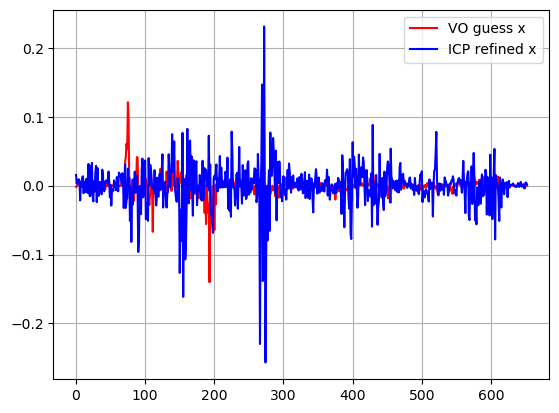

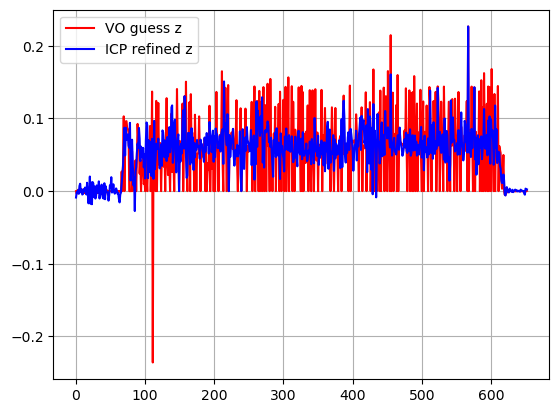

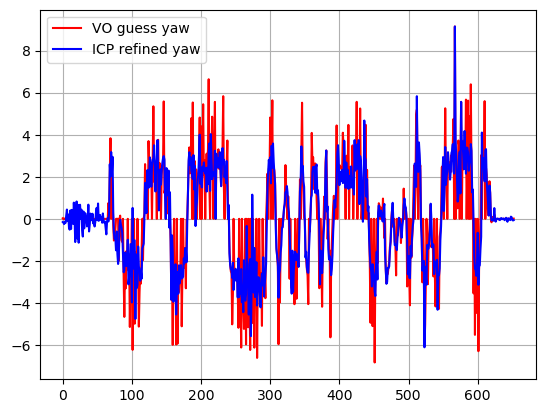

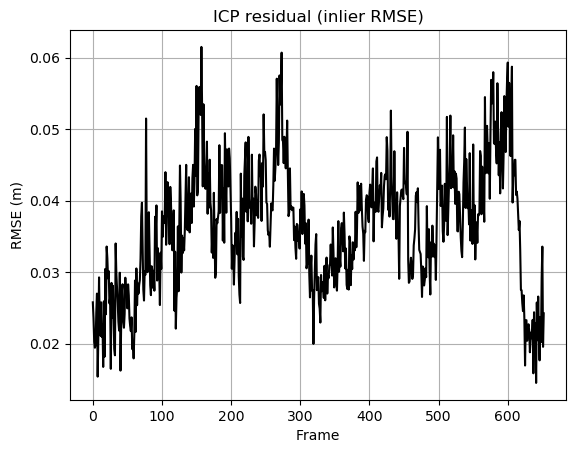

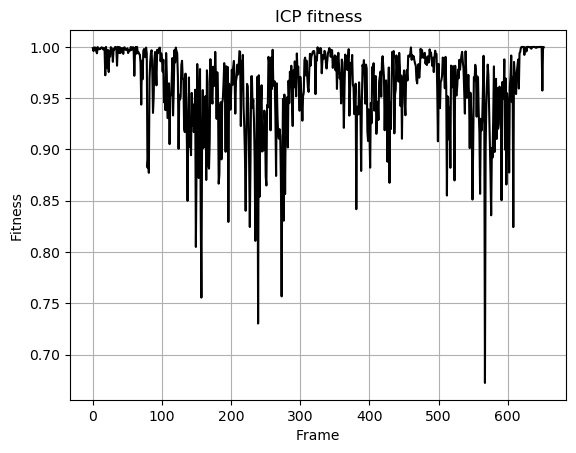

In [17]:
plt.figure()
start = 0
end = len(t_reg)
t_guess_x = [t[0,3] for t in t_guess]
t_guess_y = [t[1,3] for t in t_guess]
t_guess_z = [t[2,3] for t in t_guess]
t_guess_yaw = [np.arctan2(t[0,2], t[2,2]) for t in t_guess]

for i in range(len(t_reg)):
    t_reg[i] = project_to_se2_camera(t_reg[i])

t_reg_x = [t[0,3] for t in t_reg]
t_reg_y = [t[1,3] for t in t_reg]
t_reg_z = [t[2,3] for t in t_reg]
t_reg_yaw = [np.arctan2(t[0,2], t[2,2]) for t in t_reg]

plt.figure()
plt.plot(t_guess_x[start:end], 'r-', label='VO guess x')
plt.plot(t_reg_x[start:end], 'b-', label='ICP refined x')
plt.grid()
plt.legend()

# plt.figure()
# plt.plot(t_guess_y[start:end], 'r-', label='VO guess y')
# plt.plot(t_reg_y[start:end], 'b-', label='ICP refined y')
# plt.grid()
# plt.legend()

plt.figure()
plt.plot(t_guess_z[start:end], 'r-', label='VO guess z')
plt.plot(t_reg_z[start:end], 'b-', label='ICP refined z')
plt.grid()
plt.legend()

plt.figure()
plt.plot(np.rad2deg(t_guess_yaw[start:end]), 'r-', label='VO guess yaw')
plt.plot(np.rad2deg(t_reg_yaw[start:end]), 'b-', label='ICP refined yaw')
plt.grid()
plt.legend()

plt.figure()
plt.plot([reg.inlier_rmse for reg in reg_list], 'k-')
plt.title("ICP residual (inlier RMSE)")
plt.xlabel("Frame")
plt.ylabel("RMSE (m)")
plt.grid()


plt.figure()
plt.plot([reg.fitness for reg in reg_list], 'k-')
plt.title("ICP fitness")
plt.xlabel("Frame")
plt.ylabel("Fitness")
plt.grid()

plt.show()

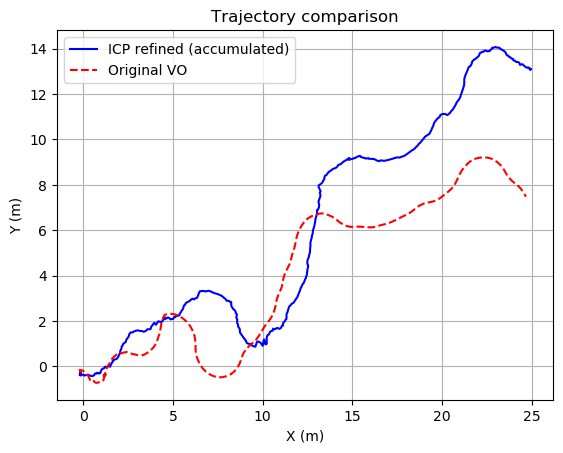

In [18]:

plt.figure()
refined_x = [T[0,3] for T in refined_poses]
refined_y = [T[1,3] for T in refined_poses]
refined_yaw = [np.arctan2(T[0,2], T[2,2]) for T in refined_poses]
original_x = [T[0,3] for T in vo_cam_pose[start_frame:end_frame]]
original_y = [T[1,3] for T in vo_cam_pose[start_frame:end_frame]]
original_yaw = [np.arctan2(T[0,2], T[2,2]) for T in vo_cam_pose[start_frame:end_frame]]
plt.plot(refined_x, refined_y, 'b-', label='ICP refined (accumulated)')
plt.plot(original_x, original_y, 'r--', label='Original VO')
plt.title("Trajectory comparison")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid()
plt.legend()


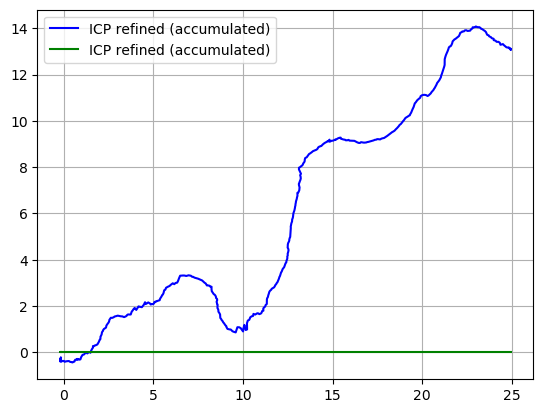

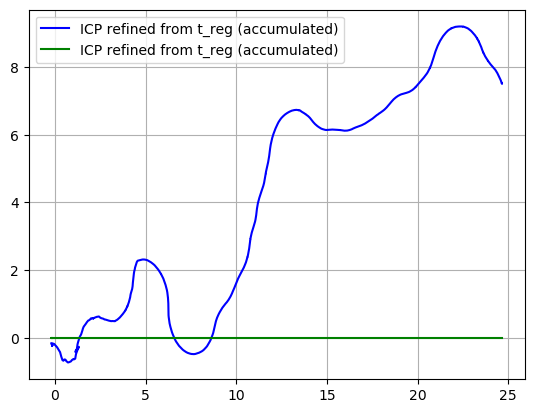

In [19]:
refined_poses_from_t_guess = [vo_cam_pose[0]]
for i in range(len(t_reg)):
    refined_poses_from_t_guess.append(refined_poses_from_t_guess[-1] @ t_guess[i])

plt.figure()
refined_x = [T[0,3] for T in refined_poses]
refined_y = [T[1,3] for T in refined_poses]
refined_z = [T[2,3] for T in refined_poses]
refined_yaw = [np.arctan2(T[0,2], T[2,2]) for T in refined_poses]
plt.plot(refined_x, refined_y, 'b-', label='ICP refined (accumulated)')
plt.plot(refined_x, refined_z, 'g-', label='ICP refined (accumulated)')
plt.grid()
plt.legend()

plt.figure()
refined_x2 = [T[0,3] for T in refined_poses_from_t_guess]
refined_y2 = [T[1,3] for T in refined_poses_from_t_guess]
refined_z2 = [T[2,3] for T in refined_poses_from_t_guess]
refined_yaw2 = [np.arctan2(T[0,2], T[2,2]) for T in refined_poses_from_t_guess]
plt.plot(refined_x2, refined_y2, 'b-', label='ICP refined from t_reg (accumulated)')
plt.plot(refined_x2, refined_z2, 'g-', label='ICP refined from t_reg (accumulated)')
plt.grid()
plt.legend()

#### target pose

In [20]:
# # object detection coorditate => x forward, y left, z up (camera coord)
# object_detect_xyz = []
# for i in range(len(object_detect)):
#     if len(object_detect[i].objects) == 1:
#         obj = object_detect[i].objects[0]
#         x = obj.position[0]
#         y = obj.position[1]
#         z = obj.position[2] 
#         object_detect_xyz.append((x,y,z))
#     elif len(object_detect[i].objects) > 1:
#         min_dist = float('inf')
#         x_best, y_best, z_best = None, None, None
#         for obj in object_detect[i].objects:
#             x = obj.position[0]
#             y = obj.position[1]
#             z = obj.position[2]
#             dist = np.hypot(x, y)
#             if dist < min_dist:
#                 min_dist = dist
#                 x_best, y_best, z_best = x, y, z
#         object_detect_xyz.append((x_best, y_best, z_best))
#     else:
#         raise ValueError("No object detected in frame {i}")

In [21]:
# object_detect_xyz = np.array(object_detect_xyz)

# plt.figure()
# plt.scatter(object_detect_xyz[:, 0], object_detect_xyz[:, 1], c='r', label='Object Detections')
# plt.show()

In [22]:
# # sphere in o3d 
# test_index = 600
# target_sphere = o3d.geometry.TriangleMesh.create_sphere(radius=0.1)
# target_sphere.paint_uniform_color([1.0, 0.0, 0.0])
# P_c_t = [-object_detect_xyz[test_index][1], -object_detect_xyz[test_index][2], object_detect_xyz[test_index][0]]  # 카메라 좌표계 (Z, -X, -Y)
# P_w_t = refined_poses[test_index] @ np.array([P_c_t[0], P_c_t[1], P_c_t[2], 1.0])
# target_sphere.translate((P_w_t[0], P_w_t[1], P_w_t[2]))

# o3d.visualization.draw_geometries([pcl_after_list[test_index], target_sphere])

In [23]:
# sphere in o3d 
test_index = 300
target_sphere = o3d.geometry.TriangleMesh.create_sphere(radius=0.1)
target_sphere.paint_uniform_color([1.0, 0.0, 0.0])
P_c_t = [-target_pose[test_index][1], -target_pose[test_index][2], target_pose[test_index][0]]  # 카메라 좌표계 (Z, -X, -Y)
P_w_t = refined_poses[test_index] @ np.array([P_c_t[0], P_c_t[1], P_c_t[2], 1.0])
target_sphere.translate((P_w_t[0], P_w_t[1], P_w_t[2]))

o3d.visualization.draw_geometries([pcl_after_list[test_index], target_sphere])

In [24]:
target_pose_refined = []
for i in range(len(target_pose)):
    P_c_t = [-target_pose[i][1], -target_pose[i][2], target_pose[i][0]]  # 카메라 좌표계 (Z, -X, -Y)
    P_w_t = refined_poses[i] @ np.array([P_c_t[0], P_c_t[1], P_c_t[2], 1.0])
    target_pose_refined.append((P_w_t[0], P_w_t[1], P_w_t[2]))


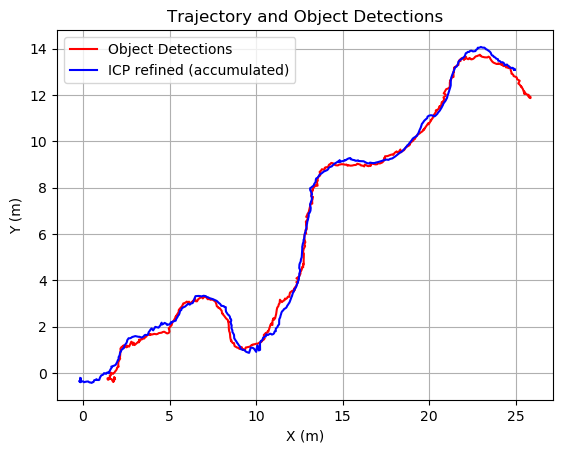

In [25]:
target_pose_x = [p[0] for p in target_pose_refined]
target_pose_y = [p[1] for p in target_pose_refined]

start = 0
end = len(target_pose_x)

plt.figure()
plt.plot(target_pose_x[start:end], target_pose_y[start:end], 'r-', label='Object Detections')
plt.plot(refined_x[start:end], refined_y[start:end], 'b-', label='ICP refined (accumulated)')
plt.title("Trajectory and Object Detections")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid()
plt.legend()

## Plotting


In [26]:
# z cliping
z_low = -0.5
z_high = 0.5

test_pcl = pcl_after_list[500]
points = np.asarray(test_pcl.points)

valid_indices = np.where((points[:,2] >= z_low) & (points[:,2] <= z_high))[0]
clipped_pcl = test_pcl.select_by_index(valid_indices)

o3d.visualization.draw_geometries([clipped_pcl])

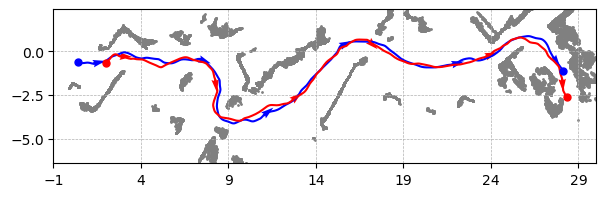

In [27]:

## FINAL PLOT ##

########## PCL ###########
z_low = -0.5
z_high = 0.5

dist_max = 3.0
pcl_2d = []


for i in range(70, len(refined_poses)):
    pcl = pcl_after_list[i]
    cur_pose = refined_poses[i]

    points = np.asarray(pcl.points)
    valid_indices = np.where((points[:,2] >= z_low) & (points[:,2] <= z_high))[0]

    valid_indices2 = np.where(np.hypot(cur_pose[0, 3] - points[:,0], cur_pose[1, 3] - points[:,1]) <= dist_max)[0]
    valid_indices = np.intersect1d(valid_indices, valid_indices2)
    
    clipped_pcl = pcl.select_by_index(valid_indices)
    points = np.asarray(clipped_pcl.points)

    pcl_2d.append(points.copy())



pcl_2d = np.vstack(pcl_2d)

# downsample for faster plotting with grid
voxel_size_plot = 0.1  # point cloud downsample voxel size (m)
pcd_plot = o3d.geometry.PointCloud()
pcd_plot.points = o3d.utility.Vector3dVector(pcl_2d)
pcd_plot = pcd_plot.voxel_down_sample(voxel_size=voxel_size_plot)
pcl_2d = np.asarray(pcd_plot.points)

########## target, agent traj ###########
start = 80
end = len(refined_poses) - 10


refined_x = [T[0,3] for T in refined_poses[start:end]]
refined_y = [T[1,3] for T in refined_poses[start:end]]

target_pose_x = [p[0] for p in target_pose_refined[start:end]]
target_pose_y = [p[1] for p in target_pose_refined[start:end]]

# smoothing
from scipy.ndimage import gaussian_filter1d
refined_x = gaussian_filter1d(refined_x, sigma=2)
refined_y = gaussian_filter1d(refined_y, sigma=2)

target_pose_x = gaussian_filter1d(target_pose_x, sigma=2)
target_pose_y = gaussian_filter1d(target_pose_y, sigma=2)

########## rotate for better view
angle = np.deg2rad(-30)
cos_a = np.cos(angle)
sin_a = np.sin(angle)
refined_x_rot = cos_a * np.array(refined_x) - sin_a * np.array(refined_y)
refined_y_rot = sin_a * np.array(refined_x) + cos_a * np.array(refined_y)
# refined_x = refined_x_rot
# refined_y = refined_y_rot
target_pose_x_rot = cos_a * np.array(target_pose_x) - sin_a * np.array(target_pose_y)
target_pose_y_rot = sin_a * np.array(target_pose_x) + cos_a * np.array(target_pose_y)
# target_pose_x = target_pose_x_rot
# target_pose_y = target_pose_y_rot
pcl_2d_rot = np.zeros_like(pcl_2d)
pcl_2d_rot[:,0] = cos_a * pcl_2d[:,0] - sin_a * pcl_2d[:,1]
pcl_2d_rot[:,1] = sin_a * pcl_2d[:,0] + cos_a * pcl_2d[:,1]
pcl_2d_rot[:,2] = pcl_2d[:,2]
# pcl_2d = pcl_2d_rot.copy()

############# FINAL PLOT #############

plt.figure(figsize=(7, 2))
plt.axis('equal')
plt.xlim(-1, 30)
plt.ylim(-5, 1)
plt.grid()

plt.plot(refined_x_rot, refined_y_rot, 'b-', label='Robot')
plt.plot(target_pose_x_rot, target_pose_y_rot, 'r-', markersize=2, label='Target')
# color with height
# z_min = np.min(pcl_2d[:,2])
# z_max = np.max(pcl_2d[:,2])
# color_map = plt.get_cmap('jet')
# colors = color_map((pcl_2d[:,2] - z_min) / (z_max - z_min))
# sc = plt.scatter(pcl_2d[:,0], pcl_2d[:,1], s=1, c=colors, alpha=0.5)
plt.scatter(pcl_2d_rot[:,0], pcl_2d_rot[:,1], s=1, c='gray', alpha=1)

# indicate start and end
plt.plot(refined_x_rot[0], refined_y_rot[0], 'bo', markersize=5)
plt.plot(refined_x_rot[-1], refined_y_rot[-1], 'bo', markersize=5)

plt.plot(target_pose_x_rot[0], target_pose_y_rot[0], 'ro', markersize=5)
plt.plot(target_pose_x_rot[-1], target_pose_y_rot[-1], 'ro', markersize=5)

# plot arrow for direction
arrow_interval = 100
for i in range(20, len(refined_x_rot), arrow_interval):
    if i + 1 < len(refined_x_rot):
        dir = np.array([refined_x_rot[i+3]-refined_x_rot[i], refined_y_rot[i+3]-refined_y_rot[i]])
        dir = dir / np.linalg.norm(dir) * 1
        plt.quiver(refined_x_rot[i], refined_y_rot[i], dir[0], dir[1],
                     scale=8, scale_units='inches', width=0.005, color='b')
for i in range(20, len(target_pose_x_rot), arrow_interval):
    if i + 1 < len(target_pose_x_rot):
        dir = np.array([target_pose_x_rot[i+3]-target_pose_x_rot[i], target_pose_y_rot[i+3]-target_pose_y_rot[i]])
        dir = dir / np.linalg.norm(dir) * 1
        plt.quiver(target_pose_x_rot[i], target_pose_y_rot[i], dir[0], dir[1],
                     scale=8, scale_units='inches', width=0.005, color='r')

# plt.xlabel("X (m)")
# plt.ylabel("Y (m)")
# xy grid every 2.5 m
plt.xticks(np.arange(-1, 31, 5))
plt.yticks(np.arange(-5, 2, 2.5))
# tick은 냅두고 grid선만 추가
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.savefig("office.pdf", bbox_inches='tight', dpi=100)
plt.show()

# plt.legend()


Mean depth dt: 0.1087362198836141
Max agent velocity: 0.9315935658679038
Max target velocity: 1.0865367326754707


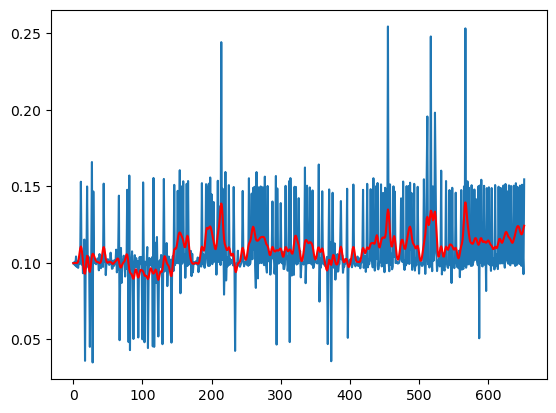

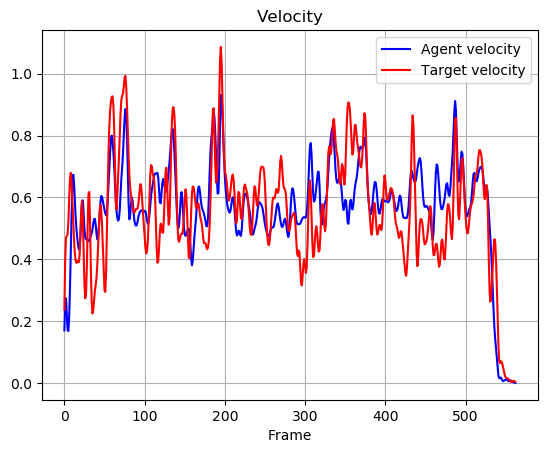

In [28]:
depth_dt = [(depth_time[i]-depth_time[i-1]).to_sec() for i in range(1, len(depth_time))]
depth_dt
plt.plot(depth_dt)
filtered_dt = gaussian_filter1d(depth_dt, sigma=2)
plt.plot(filtered_dt, 'r-')
mean_dt = np.mean(filtered_dt)
print("Mean depth dt:", mean_dt)

# get target and agent velocity

target_velocity = []
agent_velocity = []

for i in range(1, len(refined_x_rot)):
    dt = mean_dt

    dx = refined_x_rot[i] - refined_x_rot[i-1]
    dy = refined_y_rot[i] - refined_y_rot[i-1]
    # dz = refined_x_rot[i][2,3] - refined_x_rot[i-1][2,3]
    dist = np.sqrt(dx**2 + dy**2)
    agent_velocity.append(dist / dt)

    dx_t = target_pose_x_rot[i] - target_pose_x_rot[i-1]
    dy_t = target_pose_y_rot[i] - target_pose_y_rot[i-1]
    # dz_t = target_pose_y_rot[i][2] - target_pose_y_rot[i-1][2]
    dist_t = np.sqrt(dx_t**2 + dy_t**2)
    target_velocity.append(dist_t / dt)

plt.figure()
plt.plot(agent_velocity, 'b-', label='Agent velocity')
plt.plot(target_velocity, 'r-', label='Target velocity')
plt.title("Velocity")
plt.grid()
plt.legend()
# plt.ylim(0, 1.5)
plt.xlabel("Frame")
print("Max agent velocity:", np.max(agent_velocity))
print("Max target velocity:", np.max(target_velocity))

## Save Animation of plot as mp4

In [46]:
%matplotlib qt

import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(14, 3))

plt.axis('equal')
plt.xlim(-1, 30)
plt.ylim(-5, 1)

plt.plot(refined_x_rot[0], refined_y_rot[0], 'bo', markersize=5)
plt.plot(refined_x_rot[-1], refined_y_rot[-1], 'bo', markersize=5)
plt.plot(refined_x_rot[0], refined_y_rot[0], 'o', c='b')

plt.plot(target_pose_x_rot[0], target_pose_y_rot[0], 'ro', markersize=5)
plt.plot(target_pose_x_rot[-1], target_pose_y_rot[-1], 'ro', markersize=5)
plt.text(target_pose_x_rot[0]- 0.5, target_pose_y_rot[0] - 0.8, 'start', fontsize=10)
plt.text(target_pose_x_rot[-1], target_pose_y_rot[-1] - 0.7, 'end', fontsize=10)

plt.scatter(pcl_2d_rot[:,0], pcl_2d_rot[:,1], s=5, c='gray', alpha=1)


ax.set_xlim(-1, 30)
# ax.set_xlabel("x [m]", fontsize=15)
ax.set_ylim(-5, 1)
# ax.set_ylabel("y [m]", fontsize=15)
ax.set_aspect("equal")

target_line, = plt.plot([], [], 'r')
target_arrow = plt.quiver([], [], [], [], scale=8, scale_units='inches', width=0.005, color='r')
ours_line, = plt.plot([], [], 'b')
bearing_line, = plt.plot([], [], 'g', alpha=0.2)


fov = 110 * np.pi / 180 / 2
coord_frame = np.array([[0, 0],
                        [np.cos(fov), -np.sin(fov)],
                        [np.cos(fov), np.sin(fov)]]) * 0.7



yaw_list = []
for i in range(start,len(refined_poses)):
    T_w_o = T_w_c_to_T_w_o(refined_poses[i])
    yaw = np.arctan2(T_w_o[1,0], T_w_o[0,0])
    yaw_list.append(yaw+angle)

yaw_list = gaussian_filter1d(yaw_list, sigma=2)
R_w_o = np.array([[np.cos(yaw_list[0]), -np.sin(yaw_list[0])],
                  [np.sin(yaw_list[0]), np.cos(yaw_list[0])]])


ours_view_coord_frame = (R_w_o @ coord_frame.T).T
ours_view_coord_frame = ours_view_coord_frame + np.array([refined_x_rot[0], refined_y_rot[0]])
ours_view_coord_line, = plt.fill(ours_view_coord_frame[:,0], ours_view_coord_frame[:,1], 'k', linewidth=1, fill=False)

accum_length = 0
acuum_length_target = 0
bearing_line_list = []



def update_lines(num):
    # print(num)
    global accum_length, acuum_length_target
    
    target_line.set_data(target_pose_x_rot[:num], target_pose_y_rot[:num])
    ours_line.set_data(refined_x_rot[:num], refined_y_rot[:num])

    R_w_o = np.array([[np.cos(yaw_list[num]), -np.sin(yaw_list[num])],
                      [np.sin(yaw_list[num]), np.cos(yaw_list[num])]])

    ours_view_coord_frame = (R_w_o @ coord_frame.T).T
    ours_view_coord_frame = ours_view_coord_frame + np.array([refined_x_rot[num], refined_y_rot[num]])
    ours_view_coord_line.set_xy(ours_view_coord_frame)

    theta = np.arctan2(target_pose_y_rot[num] - target_pose_y_rot[num-1], target_pose_x_rot[num] - target_pose_x_rot[num-1])
    target_arrow.set_UVC(np.cos(theta), np.sin(theta))
    target_arrow.set_offsets([target_pose_x_rot[num], target_pose_y_rot[num]])

    accum_length += np.sqrt(((refined_x_rot[num] - refined_x_rot[num-1])**2 + (refined_y_rot[num] - refined_y_rot[num-1])**2))
    acuum_length_target += np.sqrt(((target_pose_x_rot[num] - target_pose_x_rot[num-1])**2 + (target_pose_y_rot[num] - target_pose_y_rot[num-1])**2))
    # plot bearing line according to the accumulated length
    if accum_length > 0.7 or num == len(refined_poses)-1 or acuum_length_target > 0.7:
        ax.plot([refined_x_rot[num], target_pose_x_rot[num]], [refined_y_rot[num], target_pose_y_rot[num]], 'g', alpha=0.2)
        # bearing_line_list.append(([cam_pose_ours_tmp[num,0], target_trajectory_tmp[num,0]], 
        #                           [cam_pose_ours_tmp[num,1], target_trajectory_tmp[num,1]]))
        # bearing_line.set_data(*zip(*bearing_line_list))
        accum_length = 0
        acuum_length_target = 0
    
    return target_line, ours_line


ani = animation.FuncAnimation(fig, update_lines, frames=range(1,len(refined_x_rot)), interval=50)
# plt.legend([ours_line, target_line], ['Drone', 'Target'], loc='upper center', bbox_to_anchor=(0.5, 1.20), ncol=4, fontsize=15)
# ani.save('/home/seungwoo/sy-sw-combination/visualization/experiment_visualization/episode_A.mp4', fps=10, dpi=300)



ani.save('office_plot.mp4', fps=10, dpi=300)
# plt.show()

%matplotlib inline


INFO - 2025-09-26 00:17:24,819 - animation - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO - 2025-09-26 00:17:24,820 - animation - MovieWriter.run: running command: ['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '4200x900', '-pix_fmt', 'rgba', '-r', '10', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', 'office_plot.mp4']


In [48]:
if end - start == len(refined_x_rot) : ### 이게 참이어야 비디오 시퀀스 맞는것!!!!
    # save rgb image as mp4
    import cv2
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter('office_rgb.mp4', fourcc, 10.0, (640,360))
    for i in range(start, end):
        img = cv2.cvtColor(rgb_list[i], cv2.COLOR_RGB2BGR)
        img = cv2.resize(img, (640,360))
        out.write(img)
    out.release()

metric measure


In [39]:
# matric for submission
def distance_to_obstacle(x, y, obstacle_points): # 25_a
    if len(obstacle_points) == 0:
        return float('inf')
    distances = np.hypot(obstacle_points[:,0] - x, obstacle_points[:,1] - y)
    return np.min(distances)

def distance_to_target(x, y, x_t, y_t): # 25_b
    return np.hypot(x - x_t, y - y_t)

def distance_between_line_seg_to_obs(x1, y1, x2, y2, obstacle_points): # 26_1
    if len(obstacle_points) == 0:
        return float('inf')
    # line segment vector
    dx = x2 - x1
    dy = y2 - y1
    if dx == 0 and dy == 0:
        return distance_to_obstacle(x1, y1, obstacle_points)
    
    # line segment 길이 제곱
    seg_len_sq = dx * dx + dy * dy

    # 각 장애물 점에 대해
    min_dist = float('inf')
    for (ox, oy, _) in obstacle_points:
        # 선분 위의 투영점 계산 (t는 0~1 사이)
        t = ((ox - x1) * dx + (oy - y1) * dy) / seg_len_sq
        t = max(0, min(1, t))  # 선분 밖으로 나가지 않도록 클램핑

        # 투영점 좌표
        proj_x = x1 + t * dx
        proj_y = y1 + t * dy

        # 장애물 점과 투영점 사이 거리 계산
        dist = np.hypot(ox - proj_x, oy - proj_y)
        if dist < min_dist:
            min_dist = dist

    return min_dist

def absolute_difference_bw_yaw_and_target_direction(x, y, yaw, x_t, y_t): # 26_2
    dir_to_target = np.arctan2(y_t - y, x_t - x)
    diff = yaw - dir_to_target
    # wrap to [-pi, pi]
    while diff > np.pi:
        diff -= 2 * np.pi
    while diff < -np.pi:
        diff += 2 * np.pi
    return abs(diff)

def distance_between_line_seg_to_obs_plot(x1, y1, x2, y2, obstacle_points):
    if len(obstacle_points) == 0:
        return float('inf')
    # line segment vector
    dx = x2 - x1
    dy = y2 - y1
    if dx == 0 and dy == 0:
        return distance_to_obstacle(x1, y1, obstacle_points)
    
    # line segment 길이 제곱
    seg_len_sq = dx * dx + dy * dy

    # 각 장애물 점에 대해
    closet_seg = None
    min_dist = float('inf')
    for (ox, oy, _) in obstacle_points:
        # 선분 위의 투영점 계산 (t는 0~1 사이)
        t = ((ox - x1) * dx + (oy - y1) * dy) / seg_len_sq
        t = max(0, min(1, t))  # 선분 밖으로 나가지 않도록 클램핑

        # 투영점 좌표
        proj_x = x1 + t * dx
        proj_y = y1 + t * dy

        # 장애물 점과 투영점 사이 거리 계산
        dist = np.hypot(ox - proj_x, oy - proj_y)
        if dist < min_dist:
            min_dist = dist
            closet_seg = (proj_x, proj_y, ox, oy)

    return min_dist, closet_seg

In [40]:
dist_from_obs = []
for i in range(len(refined_x)):
    dist = distance_to_obstacle(refined_x[i], refined_y[i], pcl_2d)
    dist_from_obs.append(dist)
    if dist < 0.3:
        print(f"Collision risk at point {i}, distance to obstacle: {dist:.2f} m")

dist_from_target = []
for i in range(len(refined_x)):
    dist = distance_to_target(refined_x[i], refined_y[i], target_pose_x[i], target_pose_y[i])
    dist_from_target.append(dist)

line_seg_dist_from_obs = []
for i in range(len(refined_x)-1):
    dist = distance_between_line_seg_to_obs(refined_x[i], refined_y[i], target_pose_x[i], target_pose_y[i], pcl_2d)
    line_seg_dist_from_obs.append(dist)
    if dist < 0.3:
        print(f"Collision risk at segment {i}-{i+1}, distance to obstacle: {dist:.2f} m")

yaw_diff_from_target_dir = []
for i in range(len(refined_x)):
    # yaw is from -y rotation
    T_w_o = T_w_c_to_T_w_o(refined_poses[i+start])
    yaw = np.arctan2(T_w_o[1,0], T_w_o[0,0])
    diff = absolute_difference_bw_yaw_and_target_direction(refined_x[i], refined_y[i], yaw, target_pose_x[i], target_pose_y[i])
    yaw_diff_from_target_dir.append(diff)



Collision risk at segment 160-161, distance to obstacle: 0.28 m
Collision risk at segment 161-162, distance to obstacle: 0.25 m
Collision risk at segment 162-163, distance to obstacle: 0.23 m
Collision risk at segment 163-164, distance to obstacle: 0.21 m
Collision risk at segment 164-165, distance to obstacle: 0.20 m
Collision risk at segment 165-166, distance to obstacle: 0.20 m
Collision risk at segment 166-167, distance to obstacle: 0.21 m
Collision risk at segment 167-168, distance to obstacle: 0.21 m
Collision risk at segment 168-169, distance to obstacle: 0.22 m
Collision risk at segment 169-170, distance to obstacle: 0.24 m
Collision risk at segment 170-171, distance to obstacle: 0.26 m
Collision risk at segment 171-172, distance to obstacle: 0.28 m
Collision risk at segment 471-472, distance to obstacle: 0.28 m
Collision risk at segment 472-473, distance to obstacle: 0.26 m
Collision risk at segment 473-474, distance to obstacle: 0.25 m
Collision risk at segment 474-475, dista

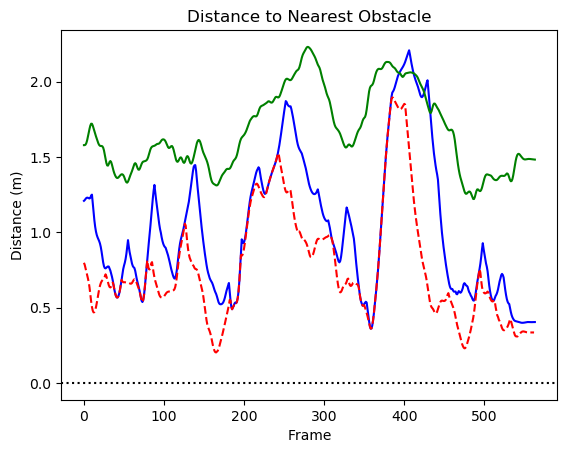

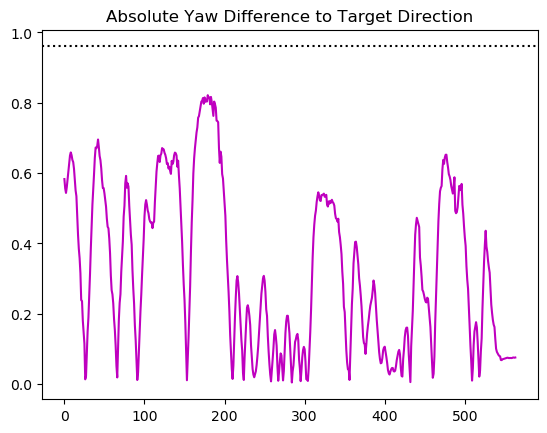

In [41]:
plt.figure()
plt.plot(dist_from_obs, 'b-', label='Distance from robot to nearest obstacle')
plt.plot(dist_from_target, 'g-', label='Distance from robot to target')
plt.plot(line_seg_dist_from_obs, 'r--', label='Distance from path segment to nearest obstacle')
plt.axhline(0.0, color='k', linestyle=':', label='Safety threshold (0.3 m)')
plt.title("Distance to Nearest Obstacle")
plt.xlabel("Frame")
plt.ylabel("Distance (m)")

plt.figure()
plt.plot(yaw_diff_from_target_dir, 'm-')
plt.axhline(np.deg2rad(110)/2, color='k', linestyle=':', label='Safety threshold (110°)')
plt.title("Absolute Yaw Difference to Target Direction")
plt.show()


In [44]:
print("Average, std, min, max distance from robot to nearest obstacle:", np.mean(dist_from_obs), np.std(dist_from_obs), np.min(dist_from_obs), np.max(dist_from_obs))
print("Average, std, min, max distance from robot to target:", np.mean(dist_from_target), np.std(dist_from_target), np.min(dist_from_target), np.max(dist_from_target))
print("Average, std, min, max distance from path segment to nearest obstacle:", np.mean(line_seg_dist_from_obs), np.std(line_seg_dist_from_obs), np.min(line_seg_dist_from_obs), np.max(line_seg_dist_from_obs))
print("Average, std, min, max absolute yaw difference to target direction (deg):", np.rad2deg(np.mean(yaw_diff_from_target_dir)), np.rad2deg(np.std(yaw_diff_from_target_dir)), np.rad2deg(np.min(yaw_diff_from_target_dir)), np.rad2deg(np.max(yaw_diff_from_target_dir)))



Average, std, min, max distance from robot to nearest obstacle: 1.0253773257568177 0.47134137370602874 0.36043358998080105 2.2079164465429906
Average, std, min, max distance from robot to target: 1.6657298342008493 0.2682258833165336 1.2206700214670594 2.2302969367687258
Average, std, min, max distance from path segment to nearest obstacle: 0.7645800650238296 0.3842051525557097 0.2023839532281934 1.8952753330898475
Average, std, min, max absolute yaw difference to target direction (deg): 18.562099772083688 13.287330510434673 0.28071708123349715 47.07021981957617


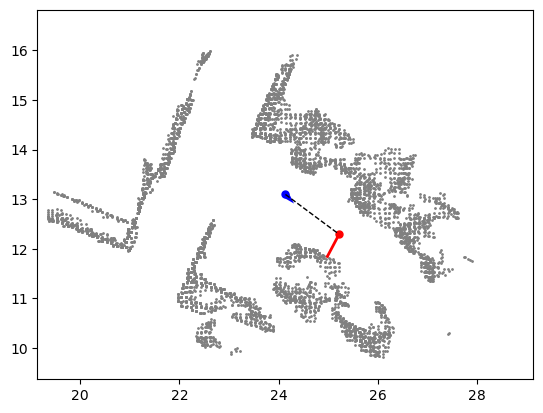

In [42]:

plt.figure()
# plot robot_pose at i
i = len(refined_x) - 50
plt.axis('equal')
plt.xlim(refined_x[i]-5, refined_x[i]+5)
plt.ylim(refined_y[i]-5, refined_y[i]+5)
# plot target_pose at i
plt.plot(target_pose_x[i], target_pose_y[i], 'ro', markersize=5)
# plot robot_pose at i
plt.plot(refined_x[i], refined_y[i], 'bo', markersize=5)
# plot arrow for robot direction

T_w_o = T_w_c_to_T_w_o(refined_poses[i+start])
yaw = np.arctan2(T_w_o[1,0], T_w_o[0,0])
dir = np.array([np.cos(yaw), np.sin(yaw)])
plt.quiver(refined_x[i], refined_y[i], dir[0], dir[1],
             scale=8, scale_units='inches', width=0.01, color='b')

# plot pcl around robot
valid_indices = np.where(np.hypot(refined_x[i] - pcl_2d[:,0], refined_y[i] - pcl_2d[:,1]) <= 5.0)[0]
clipped_pcl = pcl_2d[valid_indices]
plt.scatter(clipped_pcl[:,0], clipped_pcl[:,1], s=1, c='gray', alpha=1)
# plot line segment from robot to target
plt.plot([refined_x[i], target_pose_x[i]], [refined_y[i], target_pose_y[i]], 'k--', linewidth=1)
# plot closest point between line segment and obstacle
dist, closet_seg = distance_between_line_seg_to_obs_plot(refined_x[i], refined_y[i], target_pose_x[i], target_pose_y[i], pcl_2d)
if closet_seg is not None:
    plt.plot([closet_seg[0], closet_seg[2]], [closet_seg[1], closet_seg[3]], 'r-', linewidth=2)


KeyboardInterrupt: 

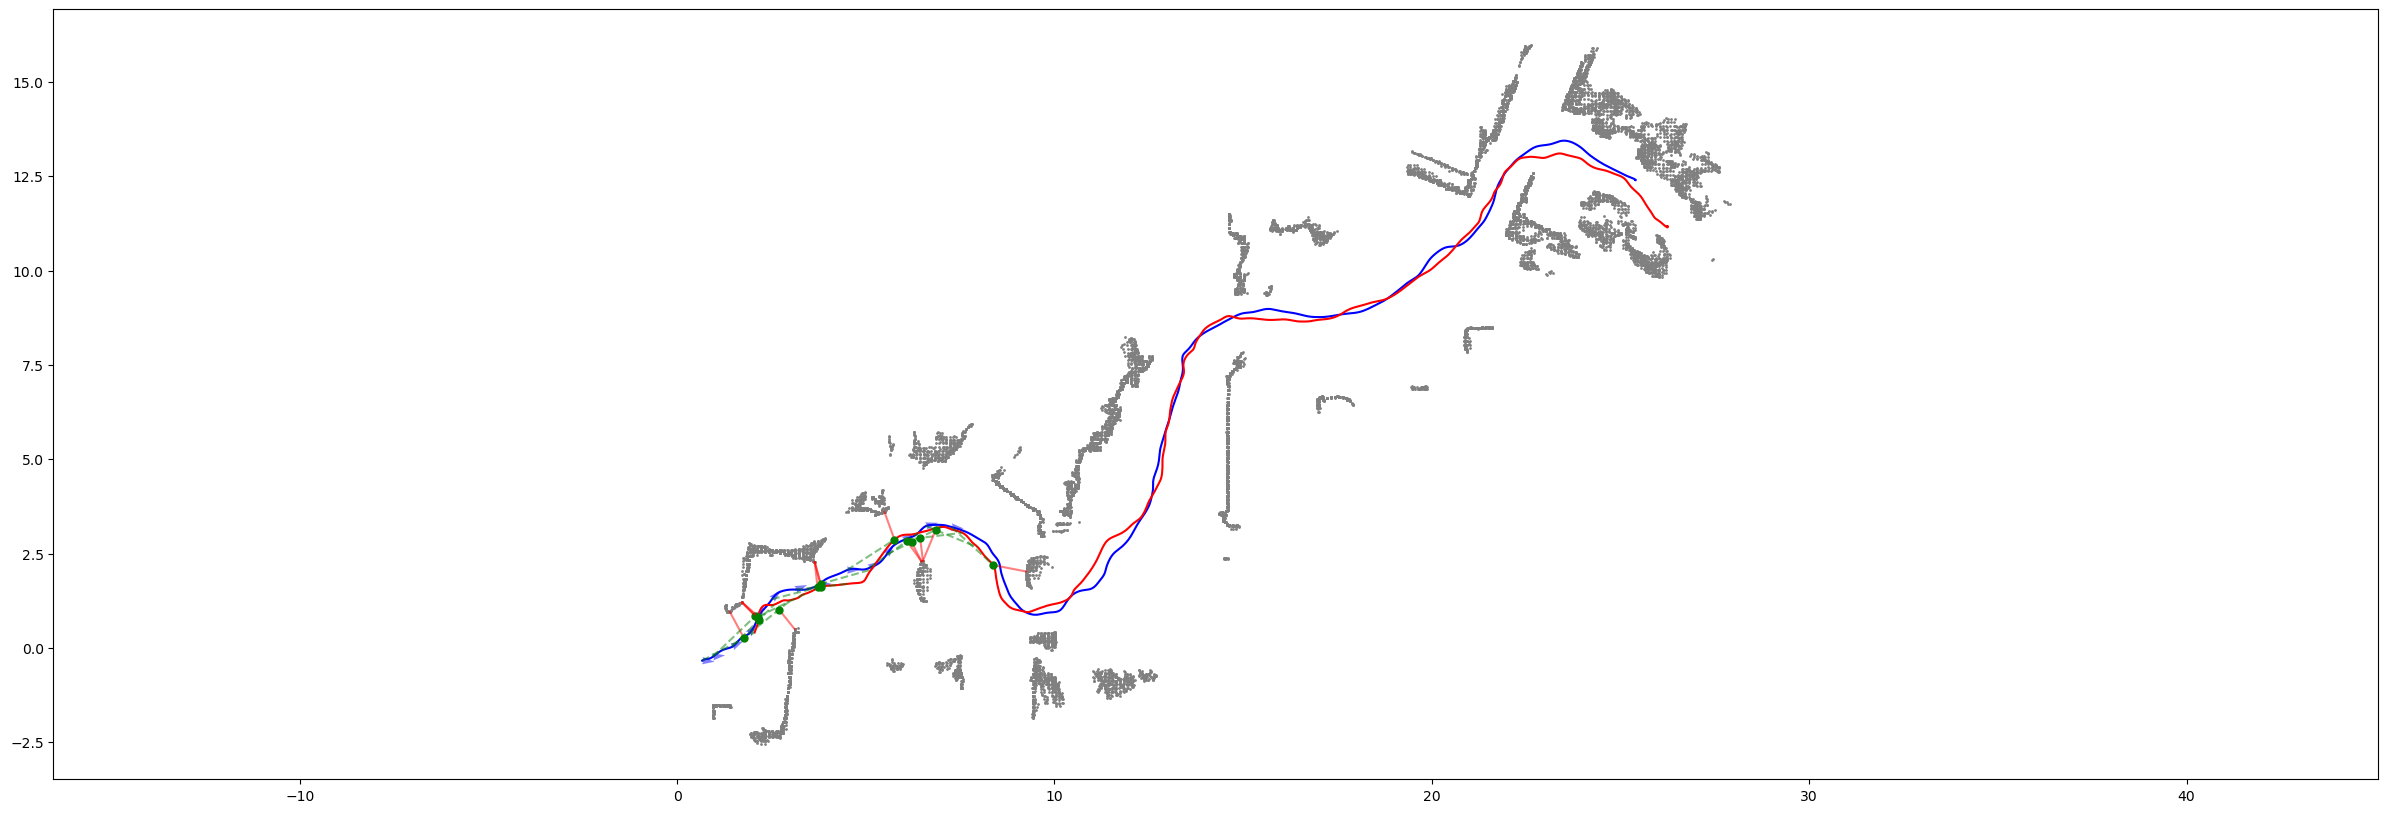

In [43]:
plt.figure(figsize=(30, 10))
plt.axis('equal')
plt.plot(refined_x, refined_y, 'b-', label='Robot')
plt.plot(target_pose_x, target_pose_y, 'r-', markersize=2, label='Target')
# color with height
# z_min = np.min(pcl_2d[:,2])
# z_max = np.max(pcl_2d[:,2])
# color_map = plt.get_cmap('jet')
# colors = color_map((pcl_2d[:,2] - z_min) / (z_max - z_min))
# sc = plt.scatter(pcl_2d[:,0], pcl_2d[:,1], s=1, c=colors, alpha=0.5)
plt.scatter(pcl_2d[:,0], pcl_2d[:,1], s=1, c='gray', alpha=1)


for i in range(len(refined_x)-1):
    dist, closet_seg = distance_between_line_seg_to_obs_plot(refined_x[i], refined_y[i], target_pose_x[i], target_pose_y[i], pcl_2d)
    if i % 10 == 0:
        if closet_seg is not None:
            proj_x, proj_y, ox, oy = closet_seg
            plt.plot([refined_x[i], target_pose_x[i]], [refined_y[i], target_pose_y[i]], 'g--', alpha=0.5)
            plt.plot([proj_x, ox], [proj_y, oy], 'r-', alpha=0.5)
            plt.plot(proj_x, proj_y, 'go', markersize=5)

            #plot yaw arrow at robot position
            T_w_o = T_w_c_to_T_w_o(refined_poses[i+start])
            yaw = np.arctan2(T_w_o[1,0], T_w_o[0,0])
            dir = np.array([np.cos(yaw), np.sin(yaw)])
            plt.quiver(refined_x[i], refined_y[i], dir[0], dir[1],
                        scale=8, scale_units='inches', width=0.005, color='b', alpha=0.5)